In [2]:
import pandas as pd
import numpy as np

# 1) Load & chuẩn hóa thời gian
df = pd.read_csv("df_forecast.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['country_name', 'date'])

In [3]:
df

,country_name,date,new_confirmed,stringency_index,cumulative_vaccine_doses_administered,average_temperature_celsius,relative_humidity
0,Afghanistan,2020-01-01,0.0,0.00,0.0,11.433333,41.708205
1,Afghanistan,2020-01-01,0.0,0.00,0.0,6.375000,63.012490
2,Afghanistan,2020-01-01,0.0,0.00,0.0,3.203704,67.876118
3,Afghanistan,2020-01-01,0.0,0.00,0.0,3.685185,77.899240
4,Afghanistan,2020-01-01,0.0,0.00,0.0,5.166667,72.300365
...,...,...,...,...,...,...,...
2716362,Yemen,2022-09-13,0.0,11.11,15726291.0,35.111111,17.975208
2716363,Yemen,2022-09-14,0.0,11.11,15743939.0,30.416667,19.234222
2716364,Yemen,2022-09-15,0.0,11.11,15761587.0,30.416667,19.234222
2716365,Yemen,2022-09-16,0.0,11.11,15779235.0,30.416667,19.234222


In [5]:
df.count()

country_name                             2716367
date                                     2716367
new_confirmed                            2716367
stringency_index                         2716367
cumulative_vaccine_doses_administered    2716367
average_temperature_celsius              2716367
relative_humidity                        2716367
dtype: int64

In [3]:
# 2) Làm mượt để giảm nhiễu
df['new_confirmed_roll7'] = (
    df.groupby('country_name')['new_confirmed']
    .rolling(7, min_periods=1).mean()
    .reset_index(level=0, drop=True)
).clip(lower=0)

In [4]:
# 3) Log-transform
df['target'] = np.log1p(df['new_confirmed_roll7'])

# Chuẩn hóa theo quốc gia + tháng (điều đặc biệt quan trọng)
df['year_month'] = df['date'].dt.to_period('M').astype(str)
stats = df.groupby(['country_name', 'year_month'])['target'].agg(['mean', 'std']).rename(
    columns={'mean': 'target_mean_period', 'std': 'target_std_period'}
)
df = df.merge(stats, on=['country_name', 'year_month'], how='left')
df['target_std'] = (df['target'] - df['target_mean_period']) / (df['target_std_period'] + 1e-6)


In [5]:
# 5) Tạo lag cho target
for l in [7, 14, 21]:
    df[f'target_lag_{l}'] = df.groupby('country_name')['target_std'].shift(l)

In [6]:
# 6) Tạo lag cho chính sách + vaccine
for l in [14, 21]:
    df[f'stringency_lag_{l}'] = df.groupby('country_name')['stringency_index'].shift(l)
    df[f'vaccine_lag_{l}'] = df.groupby('country_name')['cumulative_vaccine_doses_administered'].shift(l)

In [7]:
# 7) Mã hóa quốc gia
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['country_label'] = le.fit_transform(df['country_name'])
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['month'] = df['date'].dt.month

In [8]:
# 8) Loại NA (từ lag)
df = df.dropna().reset_index(drop=True)

In [9]:
# 9) Train / Test split
train = df[df['date'] < '2022-01-01']
test = df[df['date'] >= '2022-01-01']

features = [
    'target_lag_7', 'target_lag_14', 'target_lag_21',
    'stringency_lag_14', 'stringency_lag_21',
    'vaccine_lag_14', 'vaccine_lag_21',
    'average_temperature_celsius',
    'relative_humidity',
    'country_label',
     'dayofyear', 'weekofyear', 'month'   # ✅ NEW
]

X_train = train[features]
y_train = train['target_std']
X_test = test[features]
y_test = test['target_std']

In [10]:
# 10) Train model 
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eta': 0.02,                 # learning_rate
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'min_child_weight': 1,
    'lambda': 1.2,               # reg_lambda
    'eval_metric': 'rmse'
}

evals = [(dtrain, 'train'), (dtest, 'valid')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1500,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=200
)

[0]	train-rmse:0.54400	valid-rmse:0.52112
[123]	train-rmse:0.53396	valid-rmse:0.52179


In [11]:
# 11) Dự báo
test = test.copy()
test['pred_std'] = model.predict(dtest)

In [12]:
# 12) Chuyển ngược chuẩn hóa (đúng cột mean/std)
test['pred_log'] = test['pred_std'] * test['target_std_period'] + test['target_mean_period']
test['true_log'] = y_test * test['target_std_period'] + test['target_mean_period']


In [13]:

# 13) Chuyển log -> giá trị thật
test['pred_real'] = np.expm1(test['pred_log'])
test['true_real'] = np.expm1(test['true_log'])

y_pred_real = test['pred_real'].values
y_test_real = test['true_real'].values

# In ra 10 dòng đầu tiên của 2 cột để kiểm tra nhanh

test[['true_real', 'pred_real']]


,true_real,pred_real
16804,0.000000,0.000000
16805,0.000000,0.000000
16806,0.000000,0.000000
16807,0.000000,0.000000
16808,0.000000,0.000000
...,...,...
2715306,0.142858,0.389357
2715307,0.000001,0.359702
2715308,0.000001,0.353477
2715309,0.000001,0.365762


In [14]:
from sklearn.metrics import r2_score

# 14) Tính MAE, RMSE, SMAPE & R²
def smape(a, f):
    return 100 * np.mean(2 * np.abs(a - f) / (np.abs(a) + np.abs(f) + 1e-9))

mae = np.mean(np.abs(y_test_real - y_pred_real))
rmse = np.sqrt(np.mean((y_test_real - y_pred_real) ** 2))
r2 = r2_score(y_test_real, y_pred_real)
smape_value = smape(y_test_real, y_pred_real)

print("✅ MAE:", mae)
print("✅ RMSE:", rmse)
print("✅ R²:", r2)
print("✅ SMAPE:", smape_value)


✅ MAE: 2.8416720522345678
✅ RMSE: 91.69393591988772
✅ R²: 0.8488904201473906
✅ SMAPE: 25.474587139586202


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13848\1710609893.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
D:\New folder\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


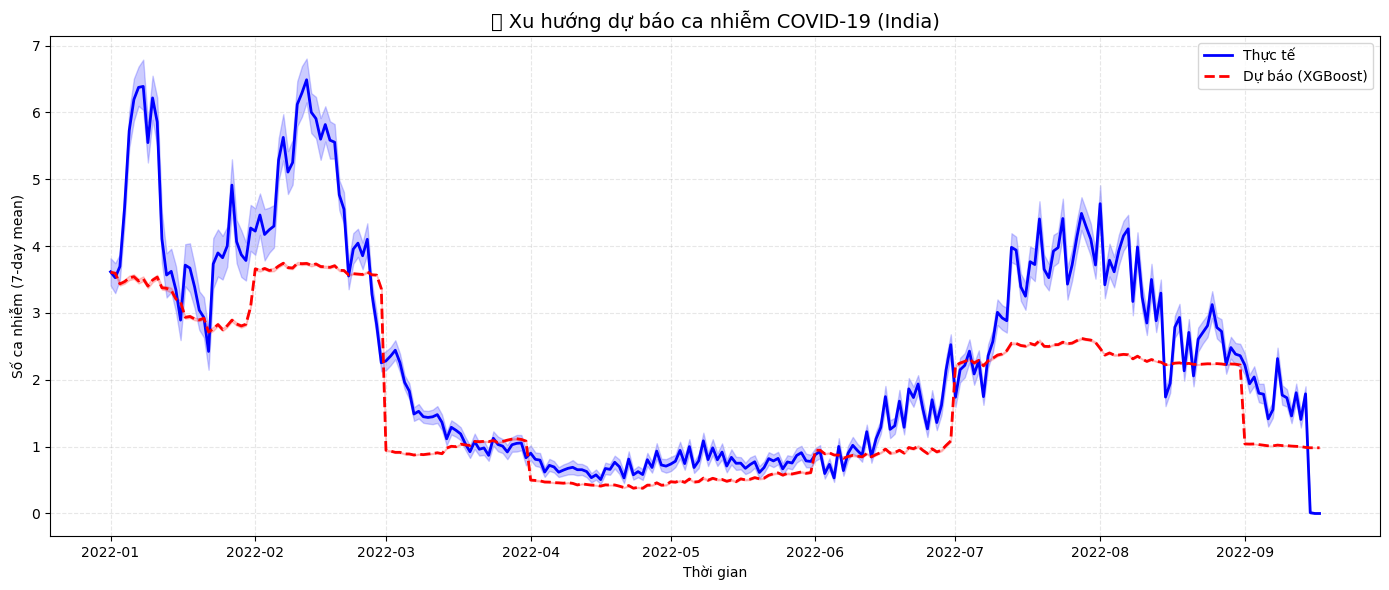

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 15) Trực quan xu hướng dự báo ---
# Chọn 1 quốc gia để xem xu hướng chi tiết
country_focus = "India"   # ⚠️ Bạn có thể đổi sang 'Thailand', 'Japan', 'India', v.v.

df_plot = test[test['country_name'] == country_focus].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(x='date', y='true_real', data=df_plot, label='Thực tế', color='blue', linewidth=2)
sns.lineplot(x='date', y='pred_real', data=df_plot, label='Dự báo (XGBoost)', color='red', linewidth=2, linestyle='--')
plt.title(f"📈 Xu hướng dự báo ca nhiễm COVID-19 ({country_focus})", fontsize=14)
plt.xlabel("Thời gian")
plt.ylabel("Số ca nhiễm (7-day mean)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()




C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23164\954359406.py:16: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from current font.
  plt.tight_layout()
D:\New folder\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


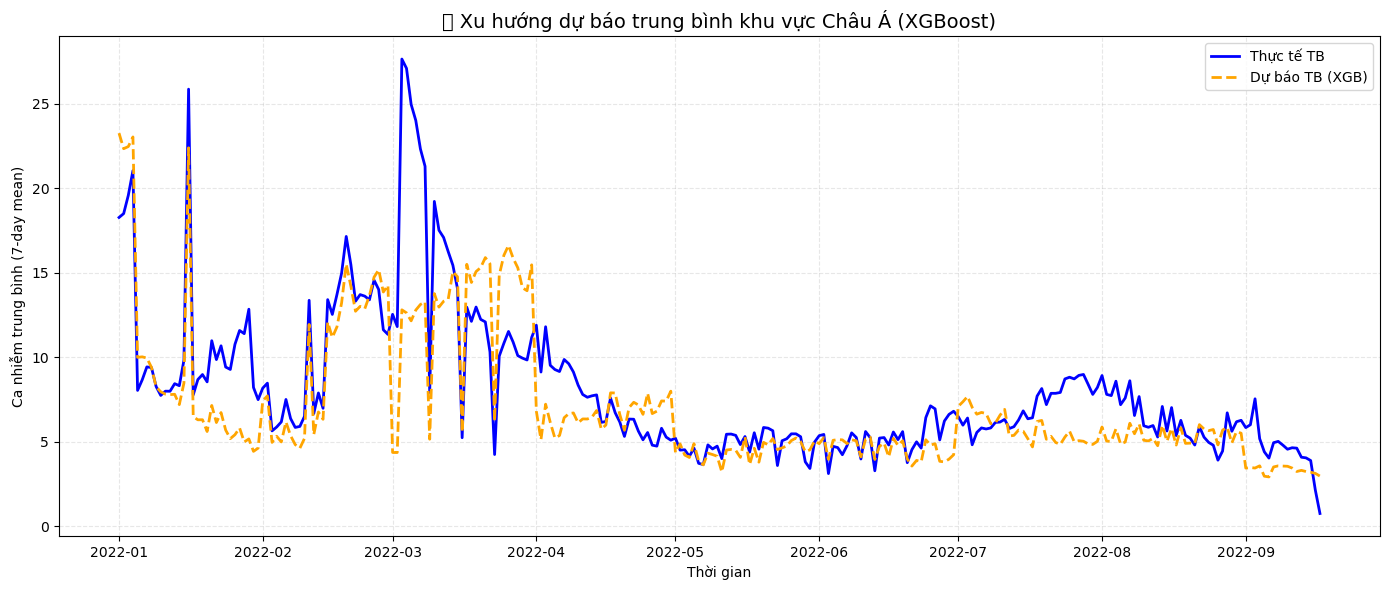

In [15]:

# --- 16) Nếu muốn xem tổng thể trung bình dự báo toàn bộ các nước ---
df_asia = (
    test.groupby('date')[['true_real', 'pred_real']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(x='date', y='true_real', data=df_asia, label='Thực tế TB', color='blue', linewidth=2)
sns.lineplot(x='date', y='pred_real', data=df_asia, label='Dự báo TB (XGB)', color='orange', linewidth=2, linestyle='--')
plt.title("🌍 Xu hướng dự báo trung bình khu vực Châu Á (XGBoost)", fontsize=14)
plt.xlabel("Thời gian")
plt.ylabel("Ca nhiễm trung bình (7-day mean)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


🔍 Feature Importance (Gain):
weekofyear: 100.6679
month: 97.8927
target_lag_21: 87.3152
target_lag_7: 87.2534
vaccine_lag_21: 77.0054
target_lag_14: 70.1322
dayofyear: 67.0452
vaccine_lag_14: 53.8380
country_label: 46.5323
stringency_lag_21: 45.4617
stringency_lag_14: 39.2688
average_temperature_celsius: 27.6693
relative_humidity: 24.7997


D:\New folder\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


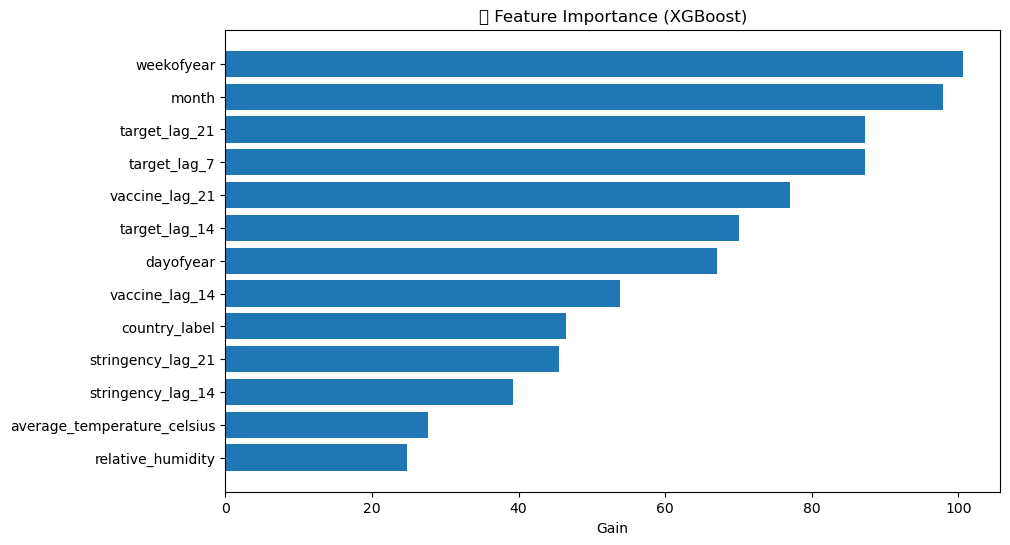

In [16]:
# 17) Feature Importance
importance = model.get_score(importance_type='gain')
importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

print("\n🔍 Feature Importance (Gain):")
for feat, score in importance:
    print(f"{feat}: {score:.4f}")

# Vẽ biểu đồ
import matplotlib.pyplot as plt

names = [x[0] for x in importance]
scores = [x[1] for x in importance]

plt.figure(figsize=(10, 6))
plt.barh(names, scores)
plt.gca().invert_yaxis()
plt.title("🎯 Feature Importance (XGBoost)")
plt.xlabel("Gain")
plt.show()


In [16]:
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Train model
from lightgbm import early_stopping, log_evaluation

model_lgb = LGBMRegressor(
    learning_rate=0.03,
    n_estimators=2000,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(100)
    ]
)


# 2) Predict (vẫn là target_std)
test['pred_std_lgb'] = model_lgb.predict(X_test)

# 3) Chuyển về log-scale
test['pred_log_lgb'] = test['pred_std_lgb'] * test['target_std_period'] + test['target_mean_period']
test['true_log_lgb'] = test['target_std'] * test['target_std_period'] + test['target_mean_period']

# 4) Chuyển về real-scale
test['pred_real_lgb'] = np.expm1(test['pred_log_lgb'])
test['true_real_lgb'] = np.expm1(test['true_log_lgb'])

y_pred_real_lgb = test['pred_real_lgb'].values
y_test_real_lgb = test['true_real_lgb'].values




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.124671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2445
[LightGBM] [Info] Number of data points in the train set: 1975196, number of used features: 13
[LightGBM] [Info] Start training from score 0.000080
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 0.273664
Early stopping, best iteration is:
[26]	valid_0's l2: 0.270149


In [17]:
test[['true_real_lgb', 'pred_real_lgb']]

,true_real_lgb,pred_real_lgb
16804,0.000000,0.000000
16805,0.000000,0.000000
16806,0.000000,0.000000
16807,0.000000,0.000000
16808,0.000000,0.000000
...,...,...
2715306,0.142858,0.363001
2715307,0.000001,0.360609
2715308,0.000001,0.365015
2715309,0.000001,0.363001


=== LIGHTGBM RESULTS ===
MAE: 2.8293631407009574
RMSE: 90.43632833761154
R²: 0.8530070141108281
SMAPE: 25.466774339863917


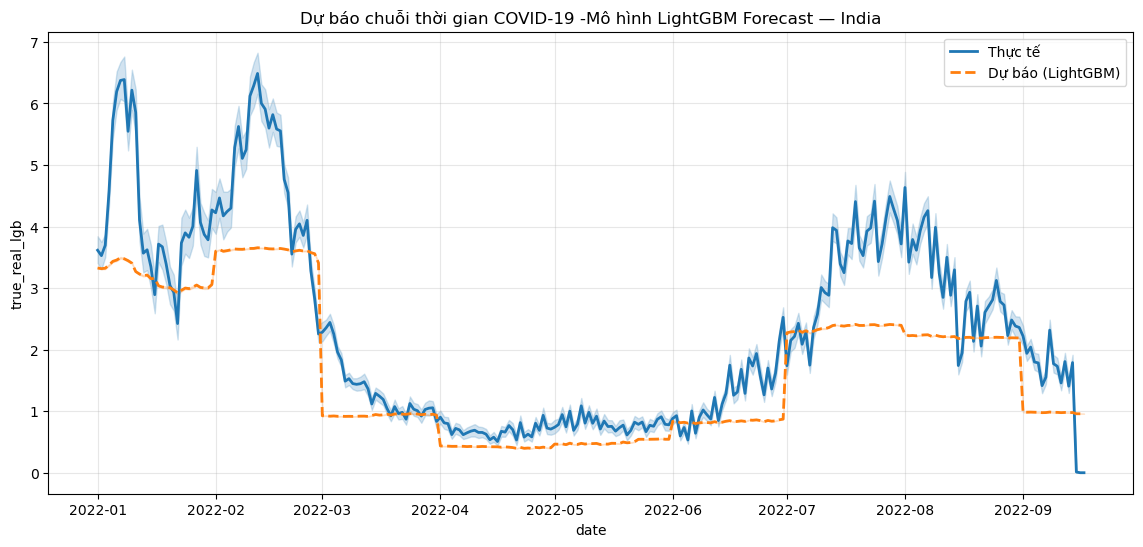

In [18]:
# 5) Metrics
def smape(a, f):
    return 100 * np.mean(2 * np.abs(a - f) / (np.abs(a) + np.abs(f) + 1e-9))

mae_lgb = mean_absolute_error(y_test_real_lgb, y_pred_real_lgb)
rmse_lgb = np.sqrt(np.mean((y_test_real_lgb - y_pred_real_lgb) ** 2))
r2_lgb = r2_score(y_test_real_lgb, y_pred_real_lgb)
smape_lgb = smape(y_test_real_lgb, y_pred_real_lgb)

print("=== LIGHTGBM RESULTS ===")
print("MAE:", mae_lgb)
print("RMSE:", rmse_lgb)
print("R²:", r2_lgb)
print("SMAPE:", smape_lgb)

# 6) Plot
country_focus = "India"
df_plot = test[test['country_name'] == country_focus].copy()

plt.figure(figsize=(14,6))
sns.lineplot(data=df_plot, x='date', y='true_real_lgb', label='Thực tế', linewidth=2)
sns.lineplot(data=df_plot, x='date', y='pred_real_lgb', label='Dự báo (LightGBM)', linewidth=2, linestyle='--')
plt.title(f"Dự báo chuỗi thời gian COVID-19 -Mô hình LightGBM Forecast — {country_focus}")
plt.grid(alpha=0.3)
plt.show()

In [21]:
import joblib

joblib.dump(model_lgb, "lightgbm_model.joblib")
print("Model saved: lightgbm_model.joblib")


Model saved: lightgbm_model.joblib
